# Chapter 6: The Attention Revolution

**Companion notebook** for *Predicting the Next Words* (Osterrieder, 2026)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josterri/predicting-the-next-words-notebooks/blob/main/ch06_the_attention_revolution.ipynb)


## What is in this notebook, and what to change in it

Three cells, from the additive attention of 2015 to the dot-product form
chapter 8 builds on.

1. **Bahdanau attention in full**, over a four-position source: alignment scores
   through a small learned scoring network, a softmax, and the context vector
   that comes out. The parameters are freshly initialised and never trained, so
   the four weights come out close to uniform, around 0.25 each. What the cell
   shows is the shape of the computation, not a result.
2. **Self-attention on a five-position sequence**, with no learned projections
   and no scaling.
3. **An attention heatmap for a French to English pair**, with the weights
   written by hand rather than learned, so the reordering between "chat noir"
   and "black cat" shows up as an off-diagonal band.

**Read cell 2's output before chapter 8, because it is the degenerate case that
chapter exists to fix.** The weight matrix comes out almost exactly the
identity: the first row is 1.0 on the diagonal and zero everywhere else, and the
output norms match the input norms to three decimal places. Every token attends
to itself and to nothing else. The reason is that the largest dot product a
random vector has is with itself, and this cell gives attention no way to
compute anything else: no projections, so a token's query is its own value, and
no scaling, so the softmax saturates on whatever gap there is. The learned
projections chapter 8 adds are what let a token attend to something other than
itself, and the division by the square root of d_k is what stops the softmax
collapsing like this. Neither is decoration.

Cell 1 draws its states from the random generator without seeding it, which is
why this notebook has a seed cell at the top. Delete that cell and run cell 1
twice: the same code gives two different sets of numbers, which is worth seeing
once.

The change worth making is in cell 2. Replace the random X with vectors you
choose, two of them nearly identical and the rest unrelated, then look at the
matrix again. The two similar tokens now attend to each other as well as to
themselves, and the identity breaks. That is the smallest possible version of
what the rest of the chapter is about.


> **This notebook was executed when it was built**, so the output under each
> cell is a real run's and you can read the file without running anything.
> Rebuild it with `python tools/build_notebook.py ch06`.


In [1]:
# Seeded before the chapter's own cells run.
#
# The cells below draw on torch. This notebook is committed with its
# output stored, and a stored number that changes on every rebuild is
# noise printed as a result. The bundle originals are read only and
# cannot be fixed where they live, so they are seeded here instead.
#
# Same seed as tools/claim_instances.py, which produced the slide
# numbers, so a number that appears in both places appears once.
import torch
torch.manual_seed(20260729)
print('seeded torch with 20260729')

seeded torch with 20260729


### 6.2.5 A Complete Worked Example

![Figure 6.3 -- Attention weight heatmap for a four-encoder-state, two-decoder-step example](../figures/fig-06-3.pdf)


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Bahdanau attention: alignment scores, weights, and context vector
d_h, d_s, d_a = 8, 8, 8  # encoder dim, decoder dim, attention dim
T_x = 4  # source sequence length

# Learnable parameters
W_h = nn.Linear(d_h, d_a, bias=False)  # projects encoder states
W_s = nn.Linear(d_s, d_a, bias=False)  # projects decoder state
v   = nn.Linear(d_a, 1,   bias=False)  # projects to scalar score

# Random encoder hidden states and decoder state
H = torch.randn(T_x, d_h)   # (T_x, d_h)
s = torch.randn(1, d_s)      # (1, d_s)

# Compute alignment scores: e_j = v^T tanh(W_s s + W_h h_j)
proj_h = W_h(H)                          # (T_x, d_a)
proj_s = W_s(s).expand(T_x, -1)         # (T_x, d_a) broadcast
scores = v(torch.tanh(proj_h + proj_s)) # (T_x, 1)

# Normalize to attention weights
alpha = F.softmax(scores, dim=0)         # (T_x, 1)

# Compute context vector as weighted sum of encoder states
context = (alpha * H).sum(dim=0)         # (d_h,)

print("Attention weights:", alpha.squeeze().detach().numpy())
print("Sum of weights:   ", alpha.sum().item())          # must be 1.0
print("Context vector:   ", context.detach().numpy())


Attention weights: [0.25529125 0.23629192 0.28362972 0.22478712]
Sum of weights:    1.0
Context vector:    [ 0.09236565 -0.10809577 -0.8387465   0.58193934 -0.6916852  -0.33393365
  0.42082772  0.2689897 ]


### 6.4.2 The Query-Key-Value Intuition


In [3]:
import torch
import torch.nn.functional as F

# Self-attention on a toy 5-position sequence, dimension 6
T, d = 5, 6
torch.manual_seed(42)

X = torch.randn(T, d)  # 5 tokens, each a 6-dim vector

# Compute pairwise dot-product scores: (T, T)
# No learned projections; no scaling (see Chapter 8 for both)
scores = X @ X.T          # shape (T, T)

# Normalize each row to get attention weights
alpha = F.softmax(scores, dim=-1)   # shape (T, T)

# Compute self-attention output: weighted sum of values (= X itself here)
Z = alpha @ X              # shape (T, d)

print("Attention weight matrix (each row sums to 1.0):")
print(alpha.detach().numpy().round(3))
print("\nRow sums:", alpha.sum(dim=-1).detach().numpy())
print("Input norms: ", X.norm(dim=-1).detach().numpy().round(3))
print("Output norms:", Z.norm(dim=-1).detach().numpy().round(3))


Attention weight matrix (each row sums to 1.0):
[[1.    0.    0.    0.    0.   ]
 [0.    0.98  0.02  0.    0.   ]
 [0.    0.008 0.99  0.    0.002]
 [0.09  0.    0.005 0.517 0.388]
 [0.    0.    0.    0.001 0.999]]

Row sums: [1. 1. 1. 1. 1.]
Input norms:  [3.627 2.826 2.989 2.019 3.268]
Output norms: [3.627 2.799 2.972 2.055 3.265]


### 6.5.3 Visualizing Attention Weights

![Figure 6.4 -- Attention weight heatmap for French-to-English translation](../figures/fig-06-4.pdf)


Attention weights shape: torch.Size([5, 5])
Row sums (should all be 1.0): tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000])
Plot saved as attention_heatmap.pdf


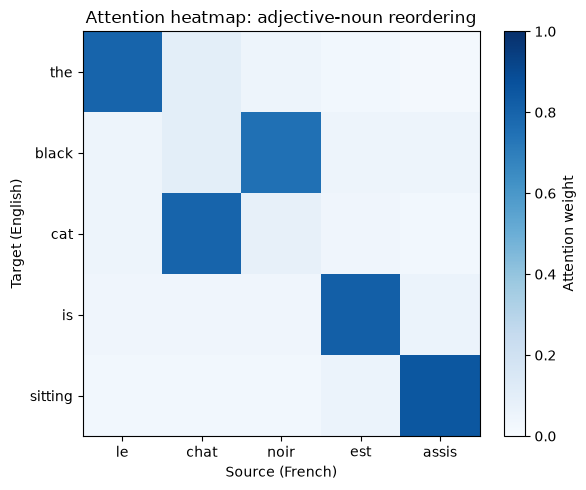

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

# Toy French-to-English attention heatmap
source = ["le", "chat", "noir", "est", "assis"]
target = ["the", "black", "cat",  "is",  "sitting"]

# Hand-designed attention weights showing reordering:
# "black" (target[1]) attends strongly to "noir" (source[2])
# "cat"   (target[2]) attends strongly to "chat" (source[1])
attn = torch.tensor([
    [0.80, 0.10, 0.05, 0.03, 0.02],  # "the"     -> "le"
    [0.05, 0.10, 0.75, 0.05, 0.05],  # "black"   -> "noir"
    [0.05, 0.80, 0.08, 0.04, 0.03],  # "cat"     -> "chat"
    [0.04, 0.04, 0.04, 0.82, 0.06],  # "is"      -> "est"
    [0.03, 0.03, 0.03, 0.06, 0.85],  # "sitting" -> "assis"
])

print("Attention weights shape:", attn.shape)
print("Row sums (should all be 1.0):", attn.sum(dim=1))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(attn.numpy(), cmap="Blues", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(source))); ax.set_xticklabels(source)
ax.set_yticks(range(len(target))); ax.set_yticklabels(target)
plt.colorbar(im, ax=ax, label="Attention weight")
ax.set_xlabel("Source (French)"); ax.set_ylabel("Target (English)")
ax.set_title("Attention heatmap: adjective-noun reordering")
plt.tight_layout(); plt.savefig("attention_heatmap.pdf"); plt.show()
print("Plot saved as attention_heatmap.pdf")


---

## Summary

This notebook demonstrated the key code examples from Chapter 6: The Attention Revolution. For the full mathematical exposition and discussion, refer to the textbook chapter.
